<a href="https://colab.research.google.com/github/nastya-kolle/mathematical-computational-modeling/blob/main/MCM_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №7. Регрессионный анализ экспериментальных данных

**Задача.** По набору экспериментальных точек `(x, y)` построить и сравнить две
регрессионные модели методом наименьших квадратов:

- линейную `y = a*x + b`;
- квадратичную `y = a*x² + b*x + c`.

Нужно вычислить коэффициенты регрессий (`numpy.polyfit`), оценить стандартную ошибку
аппроксимации (RMSE) для каждой модели, построить график с исходными точками и обеими
кривыми и сделать вывод, какая модель лучше описывает данные.


In [ ]:
import pandas
import numpy as np
import scipy
import sympy
import math
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [ ]:
x_data = np.array([2.30, 2.97, 1.51, 1.98, 0.28, 0.29, 0.24, 1.46, 1.57, 2.27,
                   2.05, 1.14, 0.87, 0.45, 2.68, 2.63, 2.11, 1.55, 0.29, 1.45,
                   1.00, 0.59, 1.12, 0.75, 2.23, 0.58, 1.25, 1.17, 0.87, 0.74,
                   2.13, 2.60, 0.70, 1.08, 2.94, 2.55, 2.04, 0.22, 1.68, 0.76])
y_data = np.array([7.94, 6.15, 14.08, 7.74, 33.80, 26.53, 37.05, 8.60, 5.45, 7.11,
                   3.14, 4.48, 11.43, 26.08, 0.51, 0.21, 2.55, 9.00, 25.76,8.83,
                   10.84, 14.90, 12.13, 10.59, 8.71, 20.59, 5.70, 8.16, 5.30, 16.78,
                   1.56, 6.48, 12.42, 6.77, 0.73, 5.80, 4.61, 35.25, 8.95, 12.64])

In [ ]:
n = len(x_data)
n

40

In [ ]:
# Линейная регрессия (y = ax + b)
#np.polyfit возвращает коэффициенты [a, b] для степени 1
coeffs_lin = np.polyfit(x_data, y_data, 1)
a_lin = coeffs_lin[0]
b_lin = coeffs_lin[1]
print(f"Коэффициент a:{a_lin}, коэффициент b:{b_lin}")

Коэффициент a:-8.858636194542681, коэффициент b:24.027238508661046


In [ ]:
#Расчет предсказанных значений и ошибок
y_lin_pred = a_lin * x_data + b_lin
errors_lin = y_data - y_lin_pred
#Стандартная ошибка аппроксимации RMSE
sigma_lin = np.sqrt(np.mean(errors_lin**2))
print(f"Уравнение: y = {a_lin:.4f} * x + {b_lin:.4f}")
print(f"Стандартная ошибка аппроксимации (sigma): {sigma_lin:.4f}\n")

Уравнение: y = -8.8586 * x + 24.0272
Стандартная ошибка аппроксимации (sigma): 5.9238



In [ ]:
#Квадратичная регрессия (y = ax*x + bx + c)
coeffs_quad = np.polyfit(x_data, y_data, 2)
a_quad = coeffs_quad[0]
b_quad = coeffs_quad[1]
c_quad = coeffs_quad[2]
print(f"Коэффициент a: {a_quad}, коэффициент b: {b_quad}, коэффициент c: {c_quad}")

Коэффициент a: 6.808296513003568, коэффициент b: -29.588663234315913, коэффициент c: 35.18028127368815


In [ ]:
#Расчет предсказанных значений и ошибок
y_quad_pred = a_quad * x_data ** 2 + b_quad * x_data + c_quad
errors_quad = y_data - y_quad_pred
#Стандартная ошибка аппроксимации RMSE
sigma_quad = np.sqrt(np.mean(errors_quad**2))
print(f"Уравнение: y = {a_quad:.4f} * x ** 2 + {b_quad:.4f} * x + {c_quad:.4f}")
print(f"Стандартная ошибка аппроксимации (sigma): {sigma_quad:.4f}\n")

Уравнение: y = 6.8083 * x ** 2 + -29.5887 * x + 35.1803
Стандартная ошибка аппроксимации (sigma): 4.2611



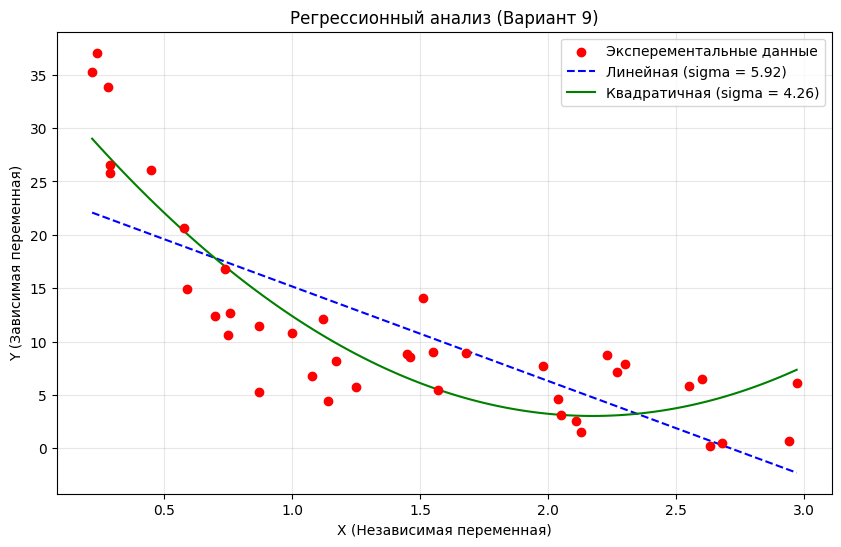

In [ ]:
#Построение графиков
#Создаем плавную  линию для отображения регрессий
x_smooth = np.linspace(min(x_data), max(x_data), 100)
y_lin_smooth = a_lin * x_smooth + b_lin
y_quad_smooth = a_quad * x_smooth ** 2 + b_quad * x_smooth + c_quad

plt.figure(figsize=(10, 6))
#Эксперементальные данные
plt.scatter(x_data, y_data, color='red', label="Эксперементальные данные", zorder=5)
#Линейная регресиия
plt.plot(x_smooth, y_lin_smooth, color='blue', linestyle='--', label=f'Линейная (sigma = {sigma_lin:.2f})')
#Квадратичная регрессия
plt.plot(x_smooth, y_quad_smooth, color='green', linestyle='-', label=f'Квадратичная (sigma = {sigma_quad:.2f})')
plt.title('Регрессионный анализ (Вариант 9)')
plt.xlabel('X (Независимая переменная)')
plt.ylabel('Y (Зависимая переменная)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
#Выводы
if (sigma_quad < sigma_lin):
  print(f"Квадратичная регрессия лучше приближает данные (sigma_quad = {sigma_quad:.4f} < sigma_lin = {sigma_lin:.4f})")
  print("Рекомендуется использовать квадратичную модель")
else:
  print(f"Линейная регрессия лучше приближает данные (sigma_lin = {sigma_lin:.4f} < sigma_quad = {sigma_quad:.4f})")
  print("Рекомендуется использовать линейную модель")

Квадратичная регрессия лучше приближает данные (sigma_quad = 4.2611 < sigma_lin = 5.9238)
Рекомендуется использовать квадратичную модель
